# Example 5 - Open-loop simulation

An open-loop simulation is the case where no state-feedback control is used. It means that only time-dependent control is used or not control at all. This kind of simulation is mainly useful for stability analysis and for cheching the trimmed behaviior (including perturbations around the trimmed conditions).

### Import atmosphere model

In [1]:
from pyaat.atmosphere import atmosCOESA
atm = atmosCOESA()

### Import gravity model

In [2]:
from pyaat.gravity import VerticalConstant
grav = VerticalConstant()

### Import Aircraft model

In [3]:
from pyaat.aircraft import Aircraft
airc = Aircraft()

### Import propulsion model

In [4]:
from pyaat.propulsion import SimpleModel
prop = SimpleModel()

### Create a system

In [5]:
from pyaat.system import system
Complete_system = system(atmosphere = atm, propulsion = prop, aircraft = airc, gravity = grav)

### Trimm at cruize condition

In [6]:
Xe, Ue = Complete_system.trimmer(condition='cruize', HE = 10000., VE = 200)

### Printing equilibrium states and controls

In [7]:
from pyaat.tools import printInfo
printInfo(Xe, Ue, frame ='body')

--------------------------------
------------ STATES ------------
------------- BODY -------------
--------------------------------
x
0.0
-------------
y
0.0
-------------
z
-10000.0
-------------
u
199.90512762194552
-------------
v
-1.4802192864744595e-21
-------------
w
6.159541415857848
-------------
phi
0.0
-------------
theta
1.7648577035616007
-------------
psi
0.0
-------------
p
4.415466257582898e-22
-------------
q
-8.573425743483335e-15
-------------
r
3.275803472664854e-22


In [8]:
printInfo(Xe, Ue, frame ='aero')

--------------------------------
------------ STATES ------------
------------- AERO -------------
--------------------------------
V
200.0
-------------
alpha
1.7648577035615969
-------------
beta
-4.240515893442633e-22
-------------
phi
0.0
-------------
theta
1.7648577035616007
-------------
psi
0.0
-------------
p
4.415466257582898e-22
-------------
q
-8.573425743483335e-15
-------------
r
3.275803472664854e-22
-------------
x0
0.0
-------------
y0
0.0
-------------
H
10000.0


In [9]:
printInfo(Xe, Ue, frame='controls')

--------------------------------
----------- CONTROLS -----------
--------------------------------
delta_p
34.65222851433093
-------------
delta_e
-2.208294991778133
-------------
delta_a
4.978810759532202e-22
-------------
delta_r
-8.268303092392625e-22


## Simulation

The open-loop simulation is carried out using the method 'propagate'. Mandatory inputs are the time of simulation TF, the equilibrium states Xe, the equilibrium control Ue, and a bolean variable called 'perturbation' which defines is applied during the simulation or not.

### Equilibrium simulation

In [10]:
solution, control = Complete_system.propagate(Xe, Ue, TF = 180, perturbation = False)

The outputs are two multidimentional arrays, containing the states over time and control over time.

In [11]:
print('Solution')
solution

Solution


array([[ 0.00000000e+00,  0.00000000e+00, -1.00000000e+04, ...,
         7.70644242e-24, -1.49634507e-16,  5.71735562e-24],
       [ 2.00000000e+00, -1.47940285e-23, -1.00000000e+04, ...,
         7.58981023e-24, -1.46384771e-16,  5.77331852e-24],
       [ 4.00000000e+00, -2.95809697e-23, -1.00000000e+04, ...,
         7.49176142e-24, -1.43387710e-16,  5.82775442e-24],
       ...,
       [ 3.59940000e+04,  9.17539299e-16, -1.00000000e+04, ...,
         4.23363783e-23,  5.90978836e-17,  3.36607499e-22],
       [ 3.59960000e+04,  9.17660133e-16, -1.00000000e+04, ...,
         4.23398348e-23,  5.90842963e-17,  3.36642365e-22],
       [ 3.59980000e+04,  9.17780967e-16, -1.00000000e+04, ...,
         4.23432914e-23,  5.90707091e-17,  3.36677231e-22]])

In [12]:
print('control')
control

control


array([[ 3.46522285e-01,  3.46522285e-01,  3.46522285e-01, ...,
         3.46522285e-01,  3.46522285e-01,  3.46522285e-01],
       [-3.85420185e-02, -3.85420185e-02, -3.85420185e-02, ...,
        -3.85420185e-02, -3.85420185e-02, -3.85420185e-02],
       [ 8.68966406e-24,  8.68966406e-24,  8.68966406e-24, ...,
         8.68966406e-24,  8.68966406e-24,  8.68966406e-24],
       [-1.44309113e-23, -1.44309113e-23, -1.44309113e-23, ...,
        -1.44309113e-23, -1.44309113e-23, -1.44309113e-23]])

The time array can be accessed directly on the system.

In [13]:
time = Complete_system.time
time

array([0.0000e+00, 1.0000e-02, 2.0000e-02, ..., 1.7997e+02, 1.7998e+02,
       1.7999e+02])

Check out the documentation for more information about the outputs.

### Ploting the results
Some plots can be generated directly using the plotter util embeeded within PyAAT.

In [14]:
from pyaat.tools import plotter
pltr = plotter()

In [15]:
pltr.states = solution
pltr.time = Complete_system.time
pltr.control = control

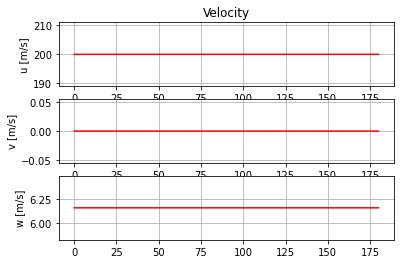

In [16]:
pltr.LinVel(frame = 'body')

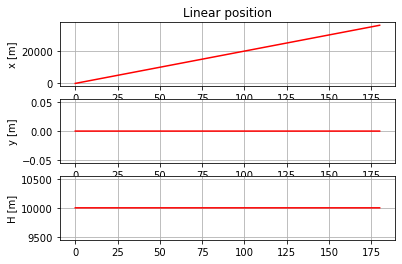

In [17]:
pltr.LinPos()

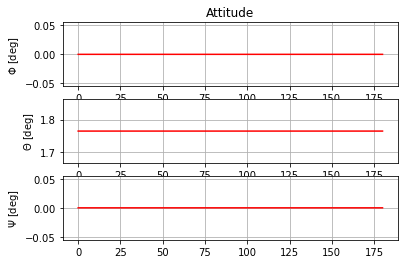

In [18]:
pltr.Attitude()

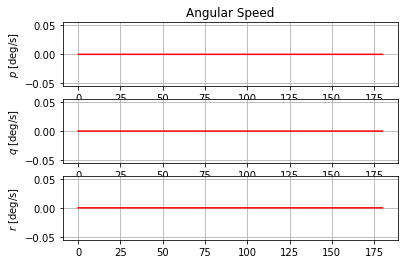

In [19]:
pltr.AngVel()

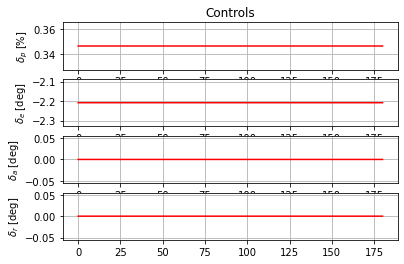

In [20]:
pltr.Controls()

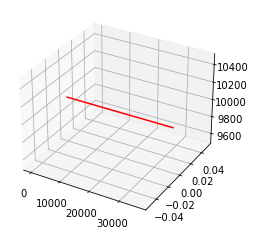

In [21]:
pltr.LinPos3D()

All states and controls remain constant over time, as expected.

## Out-of-equilibrium simulations

Sometimes we may be interested in verifying the behavior of the aircraft out of the equilibrium states. It can be done by applying perturbations.

Note that you would obtain the same result if you input a vector Xe out of equilibrium, but consider that it may cause confusion and in more advanced simulations (considering closed-loop control) it might lead to errors.

### Perturbation on states

In [22]:
solution, control = Complete_system.propagate(Xe, Ue, T0 = 0.0, TF = 30.0, dt = 0.01, perturbation = True, state = {'beta':2., 'alpha':2.})

In [23]:
pltr.states = solution
pltr.time = Complete_system.time
pltr.control = control

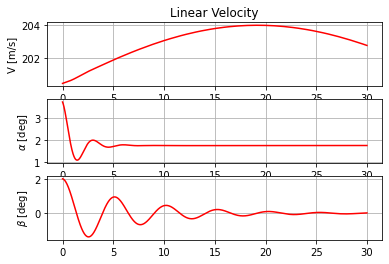

In [24]:
pltr.LinVel(frame = 'aero')

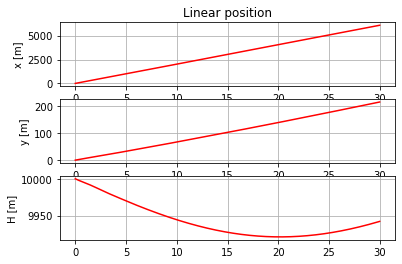

In [25]:
pltr.LinPos()

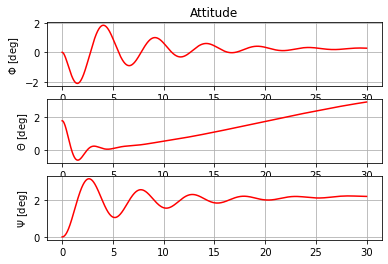

In [26]:
pltr.Attitude()

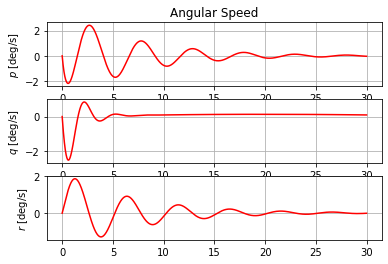

In [27]:
pltr.AngVel()

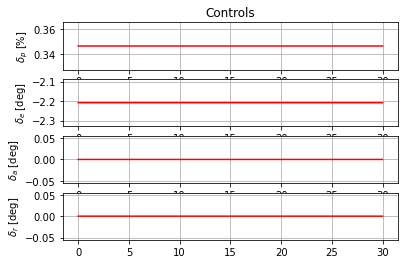

In [28]:
pltr.Controls()

### open-loop control

Some usual control inputs are also embeeded within the toolbox, such as the doublet and step.

In [29]:
from pyaat.control import doublet, step

#### Doublet input on elevator

In [30]:
doub = doublet()
doub.command = 'elevator'
doub.amplitude = 3
doub.T = 1
doub.t_init = 2

#### Step input on aileron

In [31]:
st =step()
st.command = 'aileron'
st.amplitude = 1
st.t_init = 2

In [32]:
solution, control = Complete_system.propagate(Xe, Ue, TF = 50, perturbation=True, control = [doub, st])

One can input as many control perturbation as we want, and we can combine it with states perturbations is desired.

In [33]:
pltr.states = solution
pltr.time = Complete_system.time
pltr.control = control

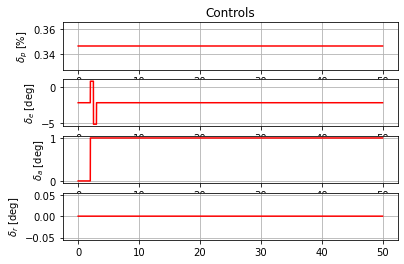

In [34]:
pltr.Controls()

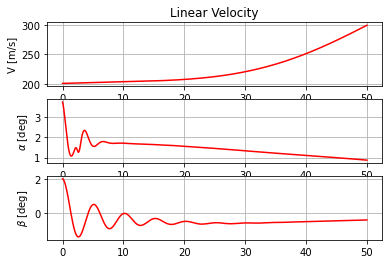

In [35]:
pltr.LinVel(frame = 'aero')

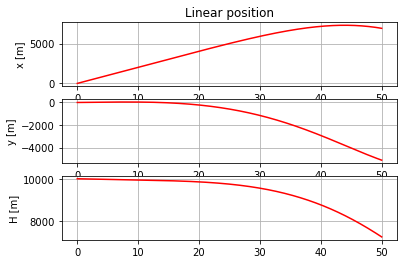

In [36]:
pltr.LinPos()

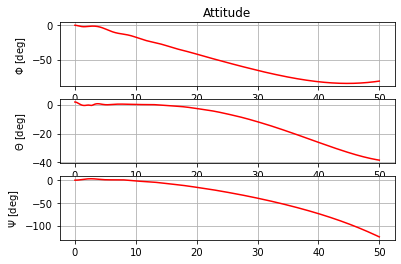

In [37]:
pltr.Attitude()

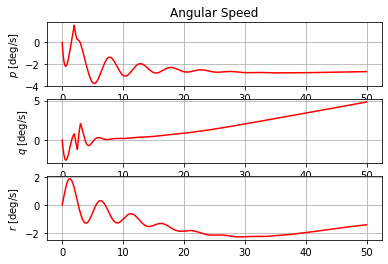

In [38]:
pltr.AngVel()

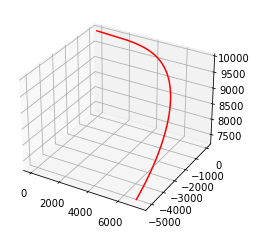

In [39]:
pltr.LinPos3D()

#### Yes, the aircraft is falling! The lateral-directional dynamics is instable (check it out using the tools from pyaat.flight_mechanics)